In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
books=pd.read_csv('bestsellers.csv')
books.head()

,Name,Author,User Rating,Reviews,Price,Year,Genre
0,10-Day Green Smoothie Cleanse,JJ Smith,4.7,17350,8,2016,Non Fiction
1,11/22/63: A Novel,Stephen King,4.6,2052,22,2011,Fiction
2,12 Rules for Life: An Antidote to Chaos,Jordan B. Peterson,4.7,18979,15,2018,Non Fiction
3,1984 (Signet Classics),George Orwell,4.7,21424,6,2017,Fiction
4,"5,000 Awesome Facts (About Everything!) (Natio...",National Geographic Kids,4.8,7665,12,2019,Non Fiction


In [4]:
print(books.info())
print(books.columns)
print(books.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550 entries, 0 to 549
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Name         550 non-null    object 
 1   Author       550 non-null    object 
 2   User Rating  550 non-null    float64
 3   Reviews      550 non-null    int64  
 4   Price        550 non-null    int64  
 5   Year         550 non-null    int64  
 6   Genre        550 non-null    object 
dtypes: float64(1), int64(3), object(3)
memory usage: 30.2+ KB
None
Index(['Name', 'Author', 'User Rating', 'Reviews', 'Price', 'Year', 'Genre'], dtype='object')
       User Rating       Reviews       Price         Year
count   550.000000    550.000000  550.000000   550.000000
mean      4.618364  11953.281818   13.100000  2014.000000
std       0.226980  11731.132017   10.842262     3.165156
min       3.300000     37.000000    0.000000  2009.000000
25%       4.500000   4058.000000    7.000000  2011.000000
50%     

In [5]:
books.drop_duplicates(inplace=True)

In [6]:
books.rename(columns={"Name":"Title", "User Rating":"Rating", "Year":"Published_year"}, inplace=True)
print(books.columns)

Index(['Title', 'Author', 'Rating', 'Reviews', 'Price', 'Published_year',
       'Genre'],
      dtype='object')


In [7]:
books['Price'].astype(float)

0       8.0
1      22.0
2      15.0
3       6.0
4      12.0
       ... 
545     8.0
546     8.0
547     8.0
548     8.0
549     8.0
Name: Price, Length: 550, dtype: float64

In [20]:
books.nlargest(10,'Price')

,Title,Author,Rating,Reviews,Price,Published_year,Genre
69,Diagnostic and Statistical Manual of Mental Di...,American Psychiatric Association,4.5,6679,105,2013,Non Fiction
70,Diagnostic and Statistical Manual of Mental Di...,American Psychiatric Association,4.5,6679,105,2014,Non Fiction
473,The Twilight Saga Collection,Stephenie Meyer,4.7,3801,82,2009,Fiction
151,Hamilton: The Revolution,Lin-Manuel Miranda,4.9,5867,54,2016,Non Fiction
346,The Book of Basketball: The NBA According to T...,Bill Simmons,4.7,858,53,2009,Non Fiction
159,Harry Potter Paperback Box Set (Books 1-7),J. K. Rowling,4.8,13471,52,2016,Fiction
271,Publication Manual of the American Psychologic...,American Psychological Association,4.5,8580,46,2009,Non Fiction
272,Publication Manual of the American Psychologic...,American Psychological Association,4.5,8580,46,2010,Non Fiction
273,Publication Manual of the American Psychologic...,American Psychological Association,4.5,8580,46,2011,Non Fiction
274,Publication Manual of the American Psychologic...,American Psychological Association,4.5,8580,46,2012,Non Fiction


In [8]:
author_count=books['Author'].value_counts()
author_count=author_count[author_count>1]

In [9]:
top_10=author_count.head()
bottom_10=author_count.tail()
print(bottom_10)
print(top_10)

Author
J. K. Rowling           2
Deborah Diesen          2
Sherri Duskey Rinker    2
Garth Stein             2
RH Disney               2
Name: count, dtype: int64
Author
Jeff Kinney                           12
Gary Chapman                          11
Rick Riordan                          11
Suzanne Collins                       11
American Psychological Association    10
Name: count, dtype: int64


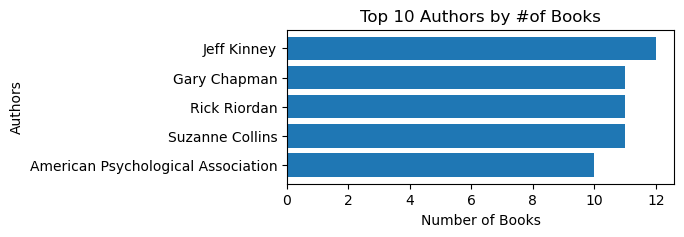

In [10]:
plt.figure(figsize=(5,2))
plt.barh(top_10.index, top_10.values)
plt.title('Top 10 Authors by #of Books')
plt.xlabel('Number of Books')
plt.ylabel('Authors')
plt.gca().invert_yaxis()
plt.show()

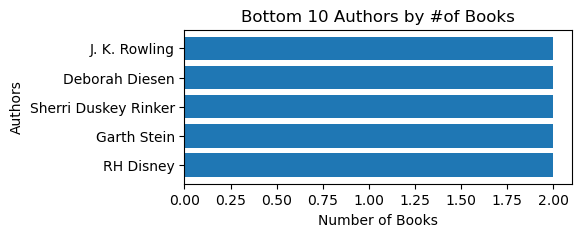

In [11]:
plt.figure(figsize=(5,2))
plt.barh(bottom_10.index, bottom_10.values)
plt.title('Bottom 10 Authors by #of Books')
plt.xlabel('Number of Books')
plt.ylabel('Authors')
plt.gca().invert_yaxis()
plt.show()

In [12]:
genre_avg_rating=books.groupby('Genre')['Rating'].mean()
print(genre_avg_rating)

Genre
Fiction        4.648333
Non Fiction    4.595161
Name: Rating, dtype: float64


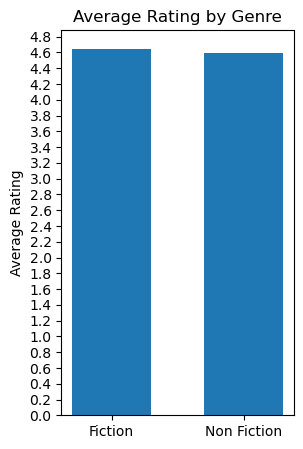

In [13]:
plt.figure(figsize=(3,5))
plt.bar(genre_avg_rating.index, genre_avg_rating.values, width=0.6)
plt.yticks(np.arange(0,5,0.2))
plt.title("Average Rating by Genre")
plt.ylabel("Average Rating")
plt.show()

(array([266., 216.,  42.,   9.,  12.,   2.,   0.,   1.,   0.,   2.]),
 array([  0. ,  10.5,  21. ,  31.5,  42. ,  52.5,  63. ,  73.5,  84. ,
         94.5, 105. ]),
 <BarContainer object of 10 artists>)

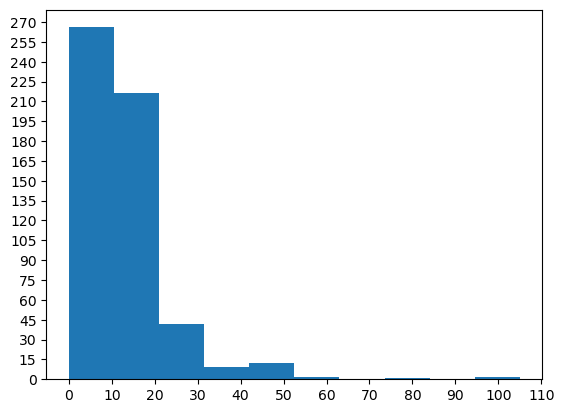

In [14]:
plt.xticks(np.arange(0,120,10))
plt.yticks(np.arange(0,280,15))
plt.hist(books['Price'])